## <u>Importing the Libraries Used : </u>
#### Data Handling & Manipulation
- pandas: Data manipulation and analysis.
- numpy: Numerical computations and array operations.
#### Machine Learning Components (Scikit-Learn)
- train_test_split: Splitting the dataset for training \ testing.
- MinMaxScaler: Feature scaling \ normalization.
- LabelEncoder: Encoding categorical labels.
#### Evaluation Metrics (Scikit-Learn)
confusion_matrix, mean_squared_error, r2_score, mean_absolute_error.
#### Machine Learning Model (Scikit-Learn)
- SVR: To implement Support Vector Regression Model.
- LinearRegression: To easily use linear regression like: Simple Linear Regression, or Multi-Linear Regression.
#### Visualization and Saving
- matplotlib.pyplot: Basic plotting and visualization.
- seaborn: Enhanced statistical visualizations.
- pickle: Model saving.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVR #for support linear regression
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)
import pickle


## <u> Data Preprocessing : </u>
- <b> Load the Dataset:</b>

The process begins by importing dataset ("obesity.csv") and performing basic exploratory analysis.
The following steps were applied:
The features <b>(X)</b> will be created by taking all columns except the final one, which will be assign as the target variable <b>(y)</b>, "NObeyesdad", now the dataset is prepared for regression tasks.

The output indicates that the dataset has 2111 observations (rows) and 17 features including the target (columns), and the target distribution reveal that the most observed class is "Obesity Type 1".

In [2]:
df = pd.read_csv('obesity.csv')
print("Size of the Dataset:", df.shape) #Dimension of the data
print("\nOutput Grouping: ",df.groupby("NObeyesdad").size()) #Group the target and count them -> indicate that the model is imbalance

#separate the features from the label 
X = df.iloc[:, :-1].copy() #Features
y = df.iloc[:, -1].copy() #Label

Size of the Dataset: (2111, 17)

Output Grouping:  NObeyesdad
Insufficient_Weight    272
Normal_Weight          287
Obesity_Type_I         351
Obesity_Type_II        297
Obesity_Type_III       324
Overweight_Level_I     290
Overweight_Level_II    290
dtype: int64


- <b>Handling Missing Values : </b>

The dataset contains both categorical and numerical features.
Removal of any rows with missing entries is a must to ensure data quality for model training.

In the used dataset, this step confirmed that no missing values were present, as the row count remained unchanged after applying the operation.

In [3]:
print("Count of Missing Values:")
print (df.isna().sum()) #Indicates no missing values in the dataset based on features
df = df.dropna() 
print("Size of the Dataset:", df.shape)

Count of Missing Values:
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64
Size of the Dataset: (2111, 17)


- <b> Features & Target Encoding : </b> 

In order to transform the categorial variables into a numerical format that machine learning algorithms can use, encoding them is a must.

All categorical features in the feature set (X) and the target variable (y) are transformed using Label Encoding. For certain columns, such as gender, family history, food preferences, and modes of transportation, the same encoding procedure is immediately applied to the main dataframe.



In [4]:
# Feature Encoding 
for col in X.columns:  
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

# Target Encoding
le_target = LabelEncoder()
y = le_target.fit_transform(y)

categorical_columns = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 
                      'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NObeyesdad']

encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le  

    

- <b>Train - Test Split : </b>

A 70-30 split is used to divide the data, with 30% set aside for testing and 70% of the instances assigned to the training set. The reproducibility of this split between runs is guaranteed by a fixed random state.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


- <b> Normalization / Scaling : </b>
  
To convert all feature values into a uniform range between 0 and 1, employment of Min-Max scaling is used. To avoid data leakage, the scaler is only fitted on the training data before applying the same transformation parameters to both the training and test sets.

In [6]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## <u> Exploratory Data Analysis : </u>

Highly linked variables that could affect model performance can be found by using a correlation heatmap, which shows the pairwise correlations between all features. In order to show how feature values differ between target groups and possibly discover significant predictors.

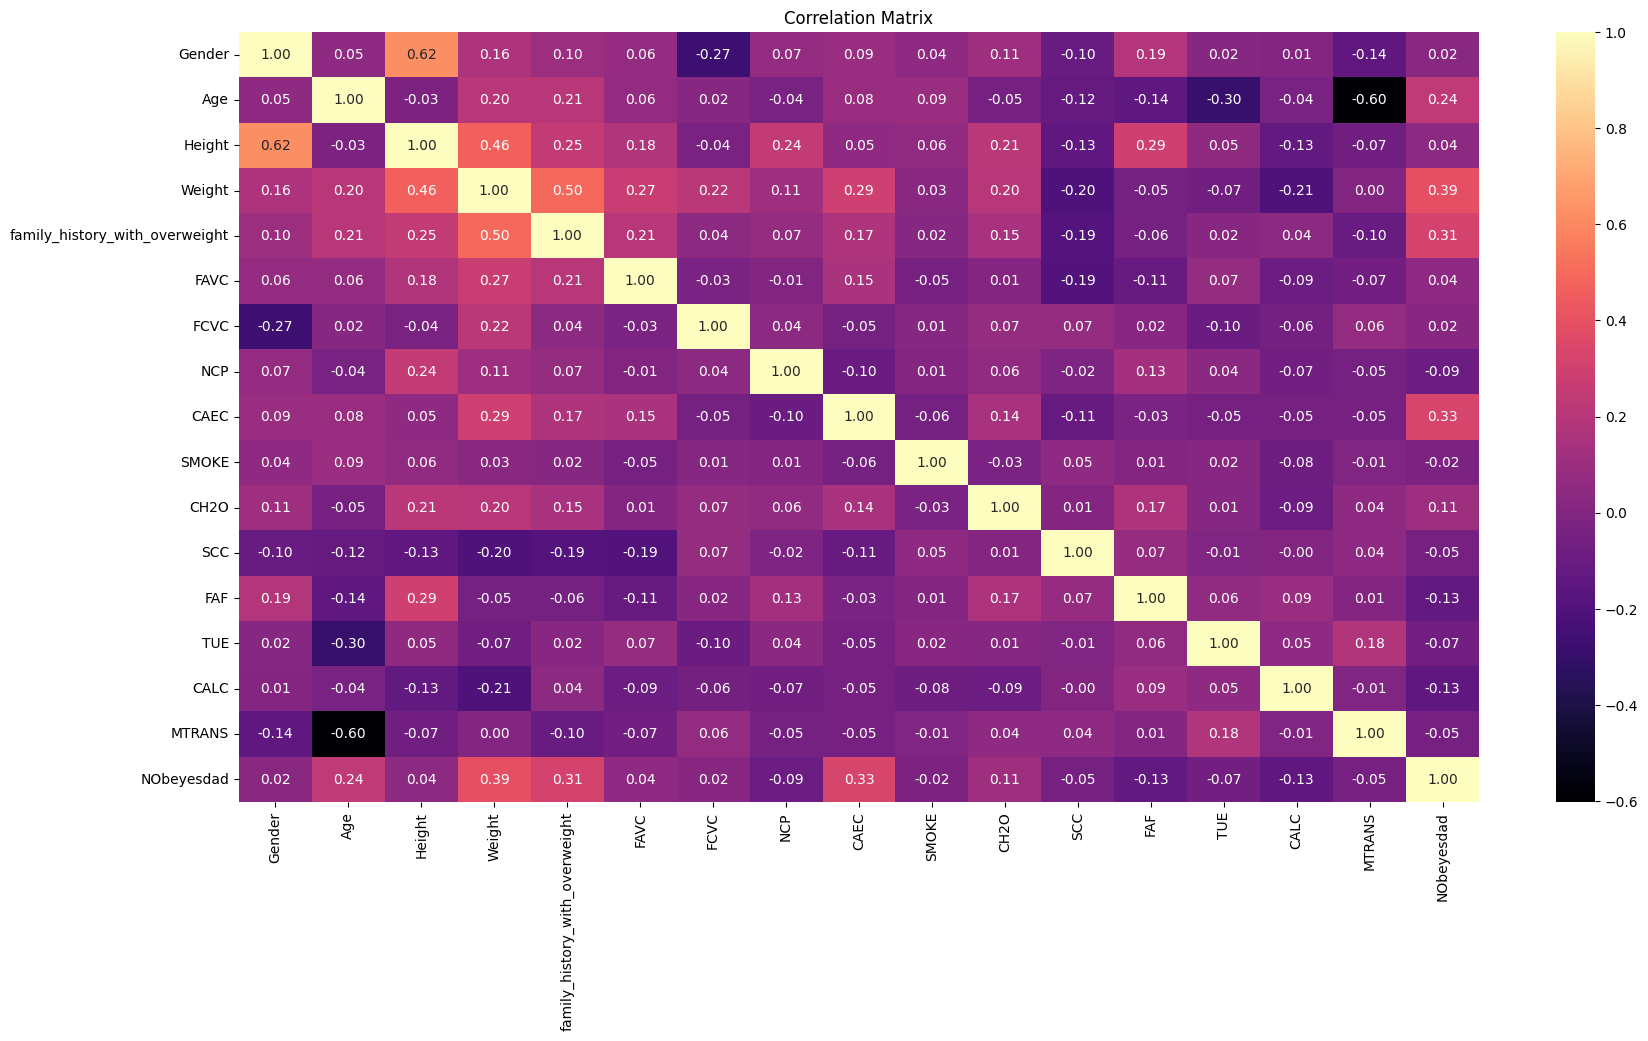

In [7]:
plt.figure(figsize=(20, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='magma', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

<i>High Impact on Obesity Level (Strong Positive Correlations): </i>

The strongest association with the aim (Obesity Levels) is <b>weight (0.39)</b>:.  Given that weight is a direct component of BMI, which is used to categorize obesity levels, it makes perfect sense. This is the most crucial aspect.

The second-strongest connection, <b>CAEC (Eating in between meals) (0.33)</b>: This behavioral factor is far more strongly associated with greater levels of obesity than it is with raw weight.

<b>Family History with Overweight (0.31)</b>: Although genetics does not dictate an individual's weight, it can affect the likelihood to gain weight.


Here is the scatter plot that represents the relation between some features with the target (NObeyesdad); Different features will output different plot according to their correlation.

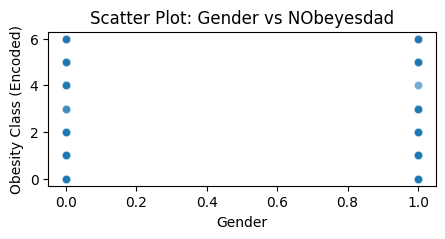

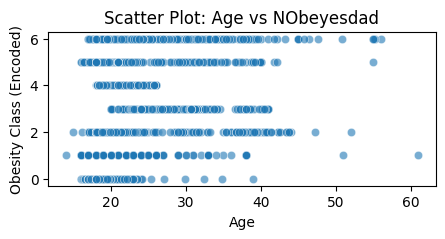

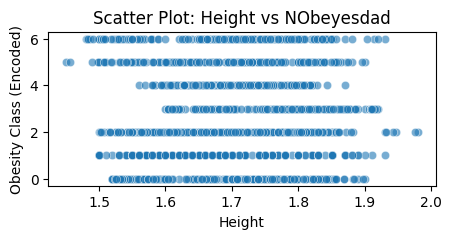

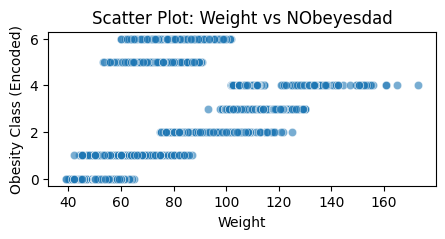

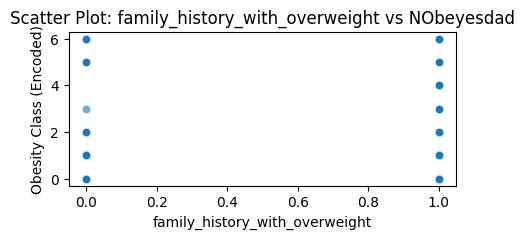

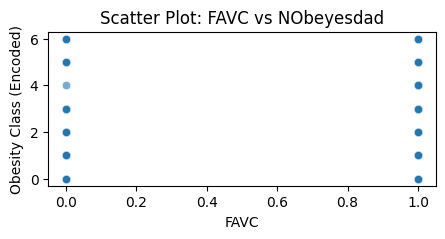

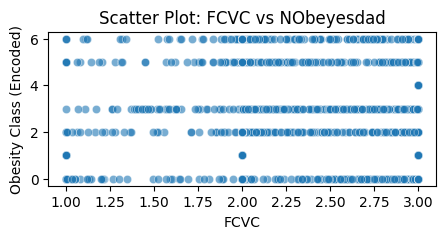

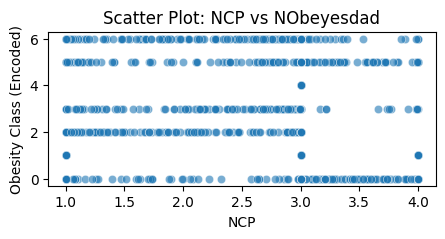

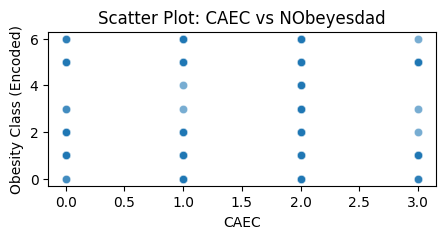

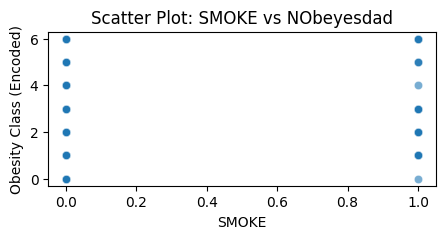

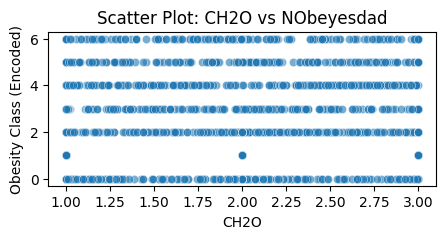

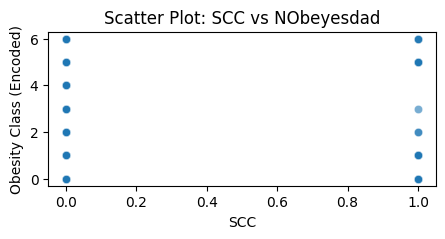

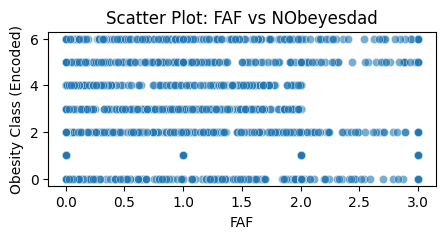

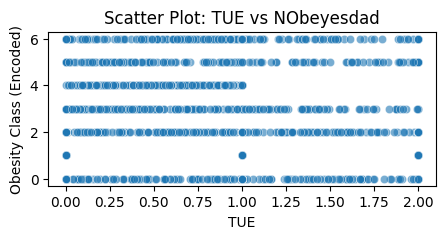

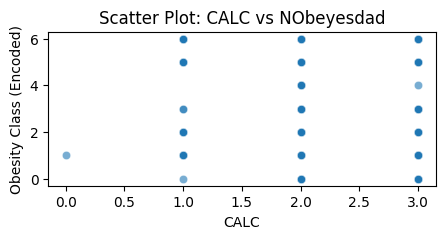

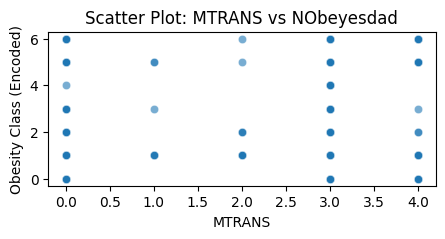

In [8]:
df_feature_target = pd.concat([X, pd.Series(y, name='NObeyesdad')], axis=1)

for col in X.columns:
    plt.figure(figsize=(5,2))
    sns.scatterplot(
        data=df_feature_target,
        x=col,
        y='NObeyesdad',
        alpha=0.6
    )
    plt.title(f"Scatter Plot: {col} vs NObeyesdad")
    plt.xlabel(col)
    plt.ylabel("Obesity Class (Encoded)")
    plt.show()


- <b>Feature Importance Analysis : </b>

Below shows the feature correlations with the target obesity variable which used to identify the most influential factors, providing insights into which characteristics have the strongest relationships with obesity classification outcomes.

The threshold of 0.05 is used, where values above this threshold will consider correlated and important, and values less will be excluded.

Unfortunately, if these chosen features are examined to predict the label class, the results will be incorrect; hence, all features are ultimately chosen.  When the related traits are observed they are seen as follows:


In [9]:
cor = df.corr()['NObeyesdad'].abs().sort_values(ascending=False)
print(cor)
#keep ( > 0.05 ) 
#drop ( < 0.05)
threshold = 0.05
selected_features = cor[cor >= threshold].index.tolist()
selected_features.remove('NObeyesdad')
print("Selected Features Based on Correlation >= 0.05:")
print(selected_features)
X = df[selected_features].copy()

print("\nNew X Shape:", X.shape)


NObeyesdad                        1.000000
Weight                            0.387643
CAEC                              0.327295
family_history_with_overweight    0.313667
Age                               0.236170
CALC                              0.134632
FAF                               0.129564
CH2O                              0.108868
NCP                               0.092616
TUE                               0.069448
SCC                               0.050679
MTRANS                            0.046202
FAVC                              0.044582
Height                            0.038986
Gender                            0.024908
SMOKE                             0.023256
FCVC                              0.018522
Name: NObeyesdad, dtype: float64
Selected Features Based on Correlation >= 0.05:
['Weight', 'CAEC', 'family_history_with_overweight', 'Age', 'CALC', 'FAF', 'CH2O', 'NCP', 'TUE', 'SCC']

New X Shape: (2111, 10)


<b> Selected Features Based on Threshold (0.05) = ['Weight', 'CAEC', 'family_history_with_overweight', 'Age', 'CALC', 'FAF', 'CH2O', 'NCP', 'TUE', 'SCC']. </b>

## <u>Model 1: Simple Learner - Multiple Linear Regression: </u>

According to the types of regression studied, the best one to be used is Multiple Linear Regression because the dataset contains many features (cant use Simple Linear Regression), and the target is NOT binay (cant use Logistic Linear Regression).

The Multi Linear Regression model (reg) was trained on the X_train and y_train data. By determining the ideal coefficients that reduce prediction error, the model discovered the mathematical link between the independent variables (features) and the dependent variable (target) during the fit phase.

In [10]:
#Model 1 - Multi Linear Regression 
reg = LinearRegression()
reg.fit(X_train,y_train)      


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


The coefficients (or weights) that the Multi Linear Regression model learned throughout the fit phase are contained in the reg.coef_ attribute.

Because all the features are considered, there is 16 different coefficients generated for each feature.

In [11]:
reg.coef_

array([ 0.02495988,  2.37976278, -0.80350716,  2.45849252,  0.86935449,
       -0.63345517, -0.26727593, -0.58972612,  2.7467176 , -0.59209848,
        0.2593751 ,  0.35142147, -0.23598423,  0.02038577, -1.1234538 ,
        0.34674703])

The Multi Linear Regression model's y-intercept is represented by the reg.intercept_ attribute.

In [12]:
reg.intercept_

np.float64(1.2180576298440449)

- <b>MLR Model Evaluation: </b>

The Multi Linear Regression model's performance was assessed on the test set after training by producing predictions (y_predMLR) and computing important metrics.  

The average magnitude of the prediction mistakes is measured by the Mean Squared Error (MSE) and its square root, the Root Mean Squared Error (RMSE), which is particularly interpretable because it is in the original units of the target variable.  A simple way to calculate the average absolute prediction error is to use the Mean Absolute Error (MAE).  Lastly, a crucial measure of the model's overall goodness-of-fit is the R-squared (R²) score, which shows the percentage of the target variable's variance that the model explains.


In [13]:
y_predMLR = reg.predict(X_test)
mse = mean_squared_error(y_test, y_predMLR)
r2 = r2_score(y_test, y_predMLR)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_predMLR)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")
print(f"Root Mean Squared Error: {rmse}")
print(f"Mean Absolute Error: {mae}")

Mean Squared Error: 2.710590389439697
R-squared: 0.2860548879269036
Root Mean Squared Error: 1.6463870715720823
Mean Absolute Error: 1.363834528556126


- <b> Residual Analysis: </b>

The assumptions of the Linear Regression model are assessed by this residual analysis.  The residuals' near-zero mean suggests that the model is impartial, and their standard deviation displays the average size of the error.  A fundamental premise of the model is validated by the scatter plot, which shows the residuals against expected values. The random distribution around zero with no discernible pattern verifies that the constant error variance (homoscedasticity) is met.

Mean of residuals: -0.059769
Standard deviation of residuals: 1.6453


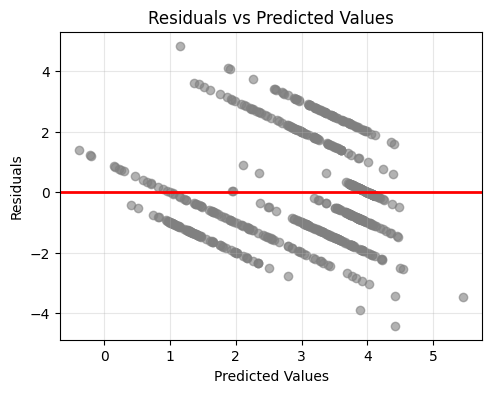

In [14]:
residuals = y_test - y_predMLR
#print(f"\nRESIDUAL ANALYSIS")
print(f"Mean of residuals: {np.mean(residuals):.6f}")
print(f"Standard deviation of residuals: {np.std(residuals):.4f}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.scatter(y_predMLR, residuals, alpha=0.6, color='grey')
plt.axhline(y=0, color='red', linestyle='-', linewidth=2)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.grid(True, alpha=0.3)

## <u>Model 2: Support Vector Regression (SVR): </u>


In order to determine the ideal hyperparameters for a Support Vector Regression (SVR) model, this part uses a methodical GridSearchCV.  In order to investigate several kernels (linear, rbf, poly), regularization strengths (C), kernel coefficients (gamma), and margin tolerances (epsilon), a thorough parameter grid was established.  The best-performing configuration was automatically identified by the search utilizing Negative Mean Squared Error and 5-fold cross-validation.  The result ensures that the SVR model was precisely adjusted for the dataset prior to evaluation by confirming that the final model was instantiated with these optimized parameters.

output best parameters : {'C': 100, 'epsilon': 0.2, 'gamma': 1, 'kernel': 'rbf'}

In [15]:
# #Model 2 - SVR 
# import time
# param_grid = {
#     'kernel': ['linear', 'rbf', 'poly'],
#     'C': [0.1, 1, 10, 100],
#     'gamma': ['scale', 'auto', 0.01, 0.1, 1],
#     'epsilon': [0.01, 0.1, 0.2, 0.5]
# }
# print("Starting SVR parameter tuning with GridSearchCV...")
# svr = SVR()
# grid_search = GridSearchCV(
#     estimator=svr,
#     param_grid=param_grid,
#     scoring='neg_mean_squared_error',
#     cv=5,
#     n_jobs=-1,
#     verbose=1
# )

# grid_search.fit(X_train, y_train)


# # Get best parameters and model
# best_params = grid_search.best_params_
# best_svr = grid_search.best_estimator_

# print("\n=== BEST PARAMETERS FOR SVR ===")
# print(f"Best parameters: {best_params}")
# print(f"Best CV score (Negative MSE): {grid_search.best_score_:.4f}")

- <b>SVR Model Evaluation : </b>

The best parameters found by GridSearchCV were used to train the optimized SVR model on the dataset.  Key metrics such as Mean Squared Error, R-squared, Root Mean Squared Error, and Mean Absolute Error were obtained from evaluating its performance on the test set.  These findings allow for a direct comparison with the performance of the Multi Linear Regression model and offer a quantitative evaluation of the predictive accuracy of the tuned SVR model.

In [16]:
best_params = {'C': 100, 'epsilon': 0.2, 'gamma': 1, 'kernel': 'rbf'}

svr_model = SVR(**best_params)
svr_model.fit(X_train, y_train)
y_predSVR = svr_model.predict(X_test)

# Calculate metrics for SVR
mse_svr = mean_squared_error(y_test, y_predSVR)
r2_svr = r2_score(y_test, y_predSVR)
rmse_svr = np.sqrt(mse_svr)
mae_svr = mean_absolute_error(y_test, y_predSVR)
print(f"Mean Squared Error: {mse_svr:.4f}")
print(f"R-squared: {r2_svr:.4f}")
print(f"Root Mean Squared Error: {rmse_svr:.4f}")
print(f"Mean Absolute Error: {mae_svr:.4f}")

Mean Squared Error: 1.2508
R-squared: 0.6706
Root Mean Squared Error: 1.1184
Mean Absolute Error: 0.6805


- <b> Residual Analysis: </b>

The performance of the SVR model was validated by analyzing its residuals, which revealed a near-zero mean that suggests impartial predictions.  The model satisfies the fundamental presumptions of homoscedasticity and appropriate functional form, as evidenced by the scatter plot of residuals vs projected values, which shows a random distribution with constant variance.

Mean of residuals: -0.000764
Standard deviation of residuals: 1.1184


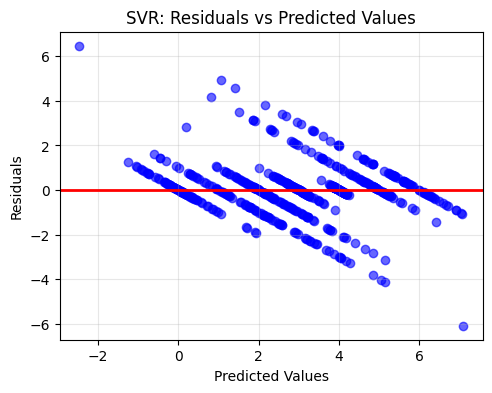

In [17]:
residuals_svr = y_test - y_predSVR

print(f"Mean of residuals: {np.mean(residuals_svr):.6f}")
print(f"Standard deviation of residuals: {np.std(residuals_svr):.4f}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(y_predSVR, residuals_svr, alpha=0.6, color='blue')
plt.axhline(y=0, color='red', linestyle='-', linewidth=2)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('SVR: Residuals vs Predicted Values')
plt.grid(True, alpha=0.3)


## <u>Model Comparison and Selection : </u>

With an R-squared value of 0.67, which indicates that it explains 67% of the variance in the target variable compared to Model 1's weak 29%, and significantly lower error rates across all measures, including a 54% reduction in Mean Squared Error (1.25 vs. 2.71) and a 50% reduction in Mean Absolute Error (0.68 vs. 1.36), Model 2 is clearly superior to Model 1 based on all evaluation metrics.

Model 2 performs noticeably better than Model 1 (R²: 0.67 vs. 0.29, MAE: 0.68 vs. 1.36), however because of its greater complexity, there are trade-offs.  Model 2 probably makes use of a more sophisticated algorithm or a larger feature set, which presents difficulties including increased processing expenses, problems with interpretability, and a higher chance of overfitting.  Model 1, on the other hand, benefits simplicity, speed, and resilience against overfitting despite having less predictive power.  In the end, Model 2 wins the trade-off since its improvements in accuracy outweigh the difficulties, as long as validation procedures are put in place to guarantee generalizability.


## <u>Model Deployment : </u>

Pickle was used to save the trained SVR model and its related preprocessing elements (scaler, label encoder, and feature names) into a pipeline for later use.  The pipeline was reloaded and used to generate a prediction on a sample input in order to illustrate the inference method.  The model produced a numerical prediction when the sample data was appropriately scaled using the saved scaler, demonstrating the model's successful end-to-end integration and its preparation stages.

In [18]:

pipeline_components = {
    'model': svr_model,  # SVR is a REGRESSION model
    'scaler': scaler,
    'label_encoder': le_target,
    'feature_names': df.drop(columns=['NObeyesdad']).columns.tolist()
}

pickle.dump(pipeline_components, open('BestModelSVR.pkl','wb'))

pipeline = pickle.load(open('BestModelSVR.pkl','rb'))

model = pipeline['model']
scaler = pipeline['scaler'] 
label_encoder = pipeline['label_encoder']
feature_names = pipeline['feature_names']

#sample = [0, 23, 1.63, 55, 1, 0, 3, 3, 0, 0, 2, 1, 2, 1, 3, 3] # encoded features -> normal weight (1)
sample = [1, 27, 1.8, 87, 0, 0, 3, 3, 2, 0, 2, 0, 2, 0, 1, 4] # encoded features -> overweight_level_I (5)

sample_df = pd.DataFrame([sample], columns=feature_names)

sample_scaled = scaler.transform(sample_df)
prediction = model.predict(sample_scaled)

rounded_prediction = round(prediction[0])
original_label = label_encoder.inverse_transform([rounded_prediction])[0]

print(f"Raw prediction: {prediction[0]:.4f}")
print(f"Rounded prediction: {rounded_prediction}")
print(f"Original class label: {original_label}")

Raw prediction: 4.7997
Rounded prediction: 5
Original class label: Overweight_Level_I
